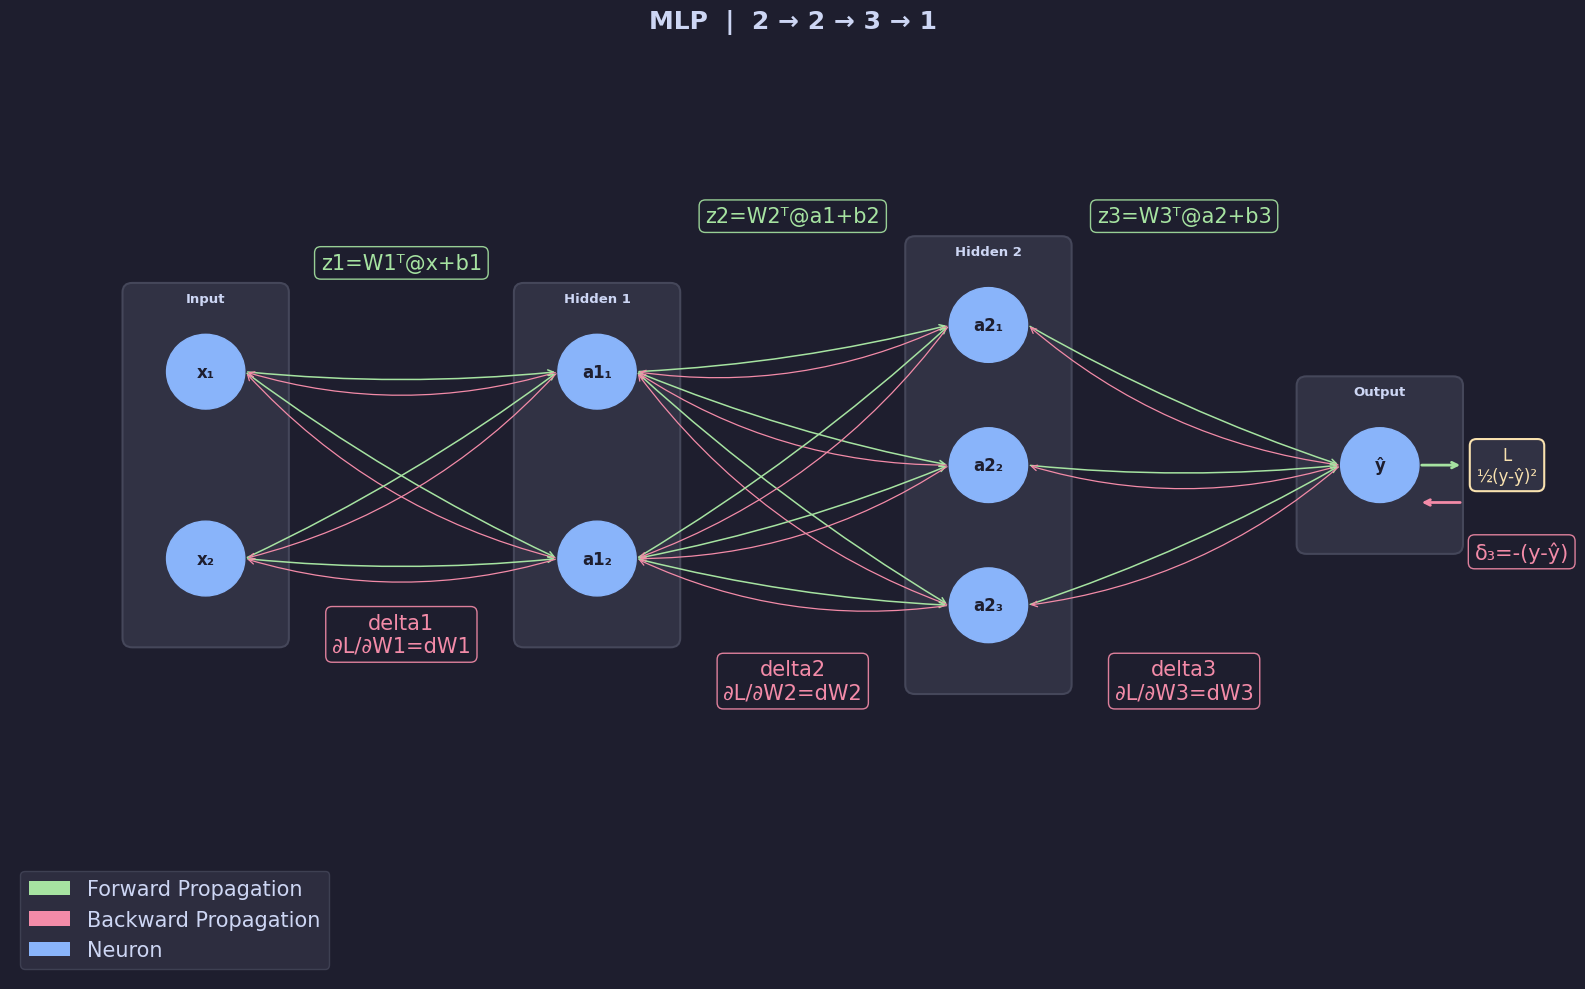

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# The map of one stage learned MLP 
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis('off')
fig.patch.set_facecolor('#1e1e2e')
ax.set_facecolor('#1e1e2e')

C_NODE  = '#89b4fa'
C_FWD   = '#a6e3a1'
C_BWD   = '#f38ba8'
C_TEXT  = '#cdd6f4'
C_LABEL = '#f9e2af'
C_LAYER = '#313244'

# neurons positions
layers = {
    'input':   {'x': 2,  'nodes': [6.5, 4.5],          'label': 'Input',    'sub': ['x₁', 'x₂']},
    'hidden1': {'x': 6,  'nodes': [6.5, 4.5],           'label': 'Hidden 1', 'sub': ['a1₁', 'a1₂']},
    'hidden2': {'x': 10, 'nodes': [7.0, 5.5, 4.0],      'label': 'Hidden 2', 'sub': ['a2₁', 'a2₂', 'a2₃']},
    'output':  {'x': 14, 'nodes': [5.5],                 'label': 'Output',   'sub': ['ŷ']},
}

node_r = 0.4

# backgorund of layars
for ldata in layers.values():
    ys = ldata['nodes']
    rect = mpatches.FancyBboxPatch(
        (ldata['x'] - 0.75, min(ys) - 0.85),
        1.5, max(ys) - min(ys) + 1.7,
        boxstyle="round,pad=0.1",
        facecolor=C_LAYER, edgecolor='#45475a', linewidth=1.5, zorder=1
    )
    ax.add_patch(rect)

# joints
conn_info = [
    ('input',   'hidden1', 'W1', 'z1=W1ᵀ@x+b1',    'dW1','delta1'),
    ('hidden1', 'hidden2', 'W2', 'z2=W2ᵀ@a1+b2',   'dW2','delta2'),
    ('hidden2', 'output',  'W3', 'z3=W3ᵀ@a2+b3',   'dW3','delta3'),
]

layer_list = list(layers.keys())

for src, dst, wname, fwd_eq, dwname, dname in conn_info:
    l1 = layers[src]
    l2 = layers[dst]
    mid_x = (l1['x'] + l2['x']) / 2

    for y1 in l1['nodes']:
        for y2 in l2['nodes']:
            # forward
            ax.annotate('', xy=(l2['x'] - node_r, y2), xytext=(l1['x'] + node_r, y1),
                arrowprops=dict(arrowstyle='->', color=C_FWD, lw=1.1,
                                connectionstyle='arc3,rad=0.05'))
            # backward
            ax.annotate('', xy=(l1['x'] + node_r, y1), xytext=(l2['x'] - node_r, y2),
                arrowprops=dict(arrowstyle='->', color=C_BWD, lw=0.9,
                                connectionstyle='arc3,rad=-0.15'))

    # label forward upside
    top_y = max(max(l1['nodes']), max(l2['nodes'])) + 1.1
    ax.text(mid_x, top_y, fwd_eq, color=C_FWD, fontsize=15, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e1e2e',
                      edgecolor=C_FWD, alpha=0.9), zorder=5)

    # label backward downside
    bot_y = min(min(l1['nodes']), min(l2['nodes'])) - 1.0
    ax.text(mid_x, bot_y, f"{dname}\n∂L/∂{wname}={dwname}",
            color=C_BWD, fontsize=15, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e1e2e',
                      edgecolor=C_BWD, alpha=0.9), zorder=5)

# neurons
for lname, ldata in layers.items():
    for j, y in enumerate(ldata['nodes']):
        c = plt.Circle((ldata['x'], y), node_r, color=C_NODE, zorder=4)
        ax.add_patch(c)
        ax.text(ldata['x'], y, ldata['sub'][j],
                color='#1e1e2e', fontsize=12, ha='center', va='center',
                fontweight='bold', zorder=6)

    top = max(ldata['nodes'])
    ax.text(ldata['x'], top + 0.75, ldata['label'],
            color=C_TEXT, fontsize=9.5, ha='center', fontweight='bold')

# box of Loss
ax.annotate('', xy=(14.85, 5.5), xytext=(14 + node_r, 5.5),
    arrowprops=dict(arrowstyle='->', color=C_FWD, lw=2.0))
ax.text(15.3, 5.5, 'L\n½(y-ŷ)²',
        color=C_LABEL, fontsize=12, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#313244',
                  edgecolor=C_LABEL, linewidth=1.5), zorder=5)

ax.annotate('', xy=(14 + node_r, 5.1), xytext=(14.85, 5.1),
    arrowprops=dict(arrowstyle='->', color=C_BWD, lw=2.0))
ax.text(15.45, 4.5, 'δ₃=-(y-ŷ)', color=C_BWD, fontsize=15, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#1e1e2e',
                  edgecolor=C_BWD, alpha=0.9), zorder=5)

# Explanation and name of plot
legend_elements = [
    mpatches.Patch(facecolor=C_FWD, label='Forward Propagation'),
    mpatches.Patch(facecolor=C_BWD, label='Backward Propagation'),
    mpatches.Patch(facecolor=C_NODE, label='Neuron'),
]
ax.legend(handles=legend_elements, loc='lower left',
          facecolor='#313244', edgecolor='#45475a',
          labelcolor=C_TEXT, fontsize=15)

ax.set_title('MLP  |  2 → 2 → 3 → 1', color=C_TEXT,
             fontsize=18, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('mlp_network.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

In [4]:
#updated parameters out put for initial setup
from IPython.display import display, Math
display(Math(r'W_1 = \begin{bmatrix} 1 & 0 \\ -1 & 0 \end{bmatrix}, \quad b_1 = \begin{bmatrix} 0 \\ 0.5 \end{bmatrix}'))
display(Math(r'W_2 = \begin{bmatrix} 0 & -2 & -1 \\ 1 & 1 & 1 \end{bmatrix}, \quad b_2 = \begin{bmatrix} 0 \\ 0 \\ 0 \end{bmatrix}'))
display(Math(r'W_3 = \begin{bmatrix} 1 \\ -1 \\ 1 \end{bmatrix}, \quad b_3 = \begin{bmatrix} 2 \end{bmatrix}'))
display(Math(r'W_1^{new} = \begin{bmatrix} 1.02808 & 0.03432 \\ -0.98596 & 0.01716 \end{bmatrix}, \quad b_1^{new} = \begin{bmatrix} 0.02808 \\ 0.53432 \end{bmatrix}'))
display(Math(r'W_2^{new} = \begin{bmatrix} 0.08265 & -2.08265 & -0.90909 \\ 1.08265 & 0.91735 & 1.09091 \end{bmatrix}, \quad b_2^{new} = \begin{bmatrix} 0.13277 \\ -0.13277 \\ 0.14606 \end{bmatrix}'))
display(Math(r'W_3^{new} = \begin{bmatrix} 1.38020 \\ -0.79598 \\ 1.29211 \end{bmatrix}, \quad b_3^{new} = \begin{bmatrix} 2.58422 \end{bmatrix}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>